# Small Object Detection in Satellite / Aerial Imagery

**Problem:** Objects in satellite images are tiny (20–50 px) inside scenes that are thousands of pixels wide. Standard detectors downscale the whole image and miss them.

**Solution demonstrated here:** YOLOv8x + **SAHI** (Slicing Aided Hyper Inference) — slice the image into 512×512 overlapping patches, detect on each patch, merge via NMS.

**Important (honest):** The model is *pretrained COCO YOLOv8x* — no fine-tuning on satellite data. We are measuring the *inference-pipeline* improvement (recall on small objects), not training a new detector.

## Setup
- Python 3.13, PyTorch 2.6 (CUDA), ultralytics 8.4, SAHI 0.12
- Run from the project root


In [1]:
import os, sys, json, time, cv2, numpy as np, torch
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Make sure we run from the project root (notebooks/ -> parent)
os.chdir(Path.cwd() if Path("data").exists() else Path.cwd().parent)
print("CWD:", Path.cwd())

print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))




CWD: C:\Users\gayat\Desktop\MLdl\TK2 SP\Satellite Object Detection
PyTorch: 2.6.0+cu124 | CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## Step 1 — The small object problem

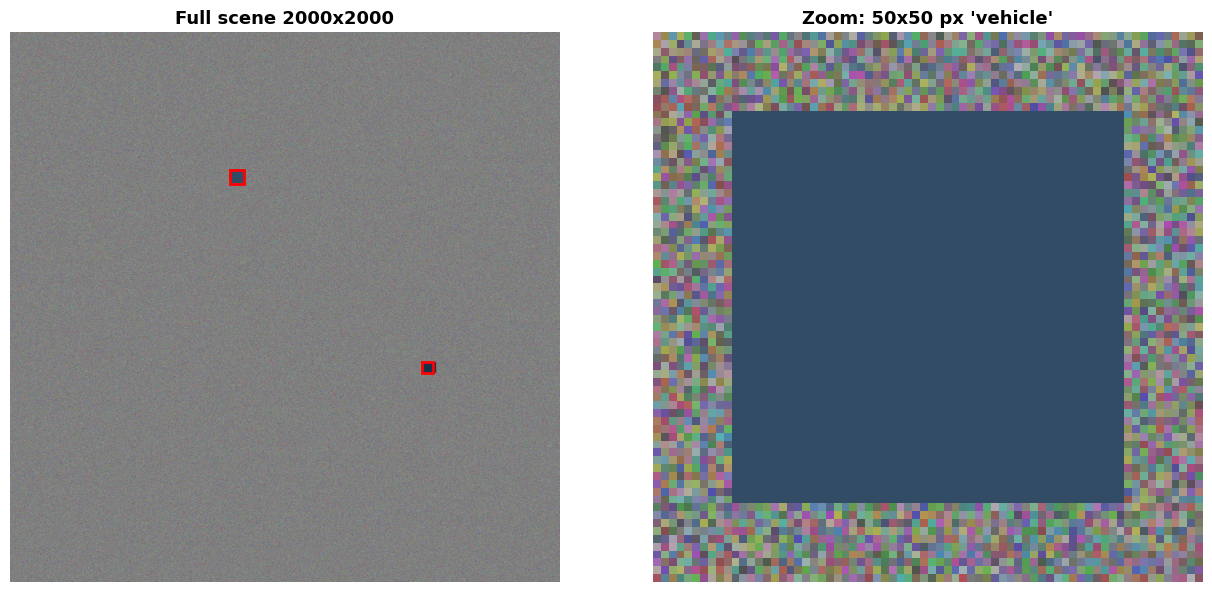

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
large_img = np.random.rand(2000, 2000, 3) * 0.4 + 0.3
large_img[500:550, 800:850] = [0.2, 0.3, 0.4]       # 50x50 'vehicle'
large_img[1200:1240, 1500:1550] = [0.1, 0.2, 0.3]   # 40x40 'vehicle'
axes[0].imshow(large_img)
axes[0].set_title("Full scene 2000x2000", fontsize=13, fontweight="bold")
axes[0].add_patch(plt.Rectangle((800,500),50,50,fill=False,edgecolor="red",lw=2))
axes[0].add_patch(plt.Rectangle((1500,1200),40,40,fill=False,edgecolor="red",lw=2))
axes[0].axis("off")
zoom = large_img[490:560, 790:860]
axes[1].imshow(zoom)
axes[1].set_title("Zoom: 50x50 px 'vehicle'", fontsize=13, fontweight="bold")
axes[1].axis("off")
plt.tight_layout(); plt.show()



A 50×50 target in a 2000×2000 image is 0.004% of pixels. After downscaling to YOLO's 640px input, it becomes ~16px — often below the detection threshold.

## Step 2 — Real data

We use 3 real aerial images (from the SAHI project itself) that contain small vehicles/boats/trucks. Downloaded in `scripts/download_data.py`.

In [3]:
!python scripts/download_data.py



DOWNLOADING DATA FOR SMALL OBJECT DETECTION DEMO
  [skip] small_vehicles_1.jpg already present
  [skip] terrain_2.png already present
  [skip] obb_test_image.png already present

Manifest written to data\manifest.json
3 images ready in data/


small_vehicles_1.jpg      1068x580px  (1815 KB)
terrain_2.png             1024x682px  (2046 KB)
obb_test_image.png        1920x1080px  (6075 KB)


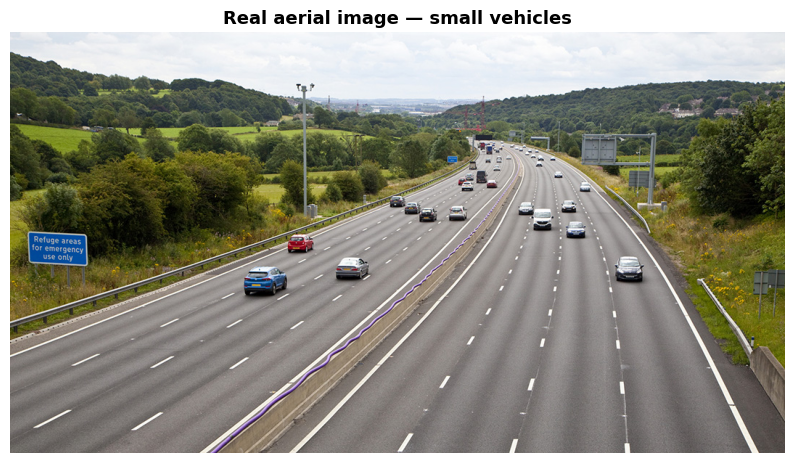

In [4]:
DATA_DIR = Path("data")
manifest = json.loads((DATA_DIR / "manifest.json").read_text())
images = [DATA_DIR / f for f in manifest["images"]]
for img in images:
    im = cv2.imread(str(img))
    h, w = im.shape[:2]
    print(f"{img.name:24s}  {w}x{h}px  ({im.size/1024:.0f} KB)")

img = cv2.imread(str(images[0]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb); plt.axis("off")
plt.title("Real aerial image — small vehicles", fontsize=13, fontweight="bold"); plt.show()



## Step 3 — Baseline: whole-image YOLOv8x

Run the pretrained model on the *full* image. The image gets downscaled to 640px, so small objects shrink.

In [5]:
from ultralytics import YOLO
model = YOLO("yolov8x.pt")  # auto-downloads COCO weights on first use

for img in images:
    res = model.predict(str(img), conf=0.25, verbose=False)
    n = len(res[0].boxes)
    print(f"{img.name:24s} baseline detections: {n}")



small_vehicles_1.jpg     baseline detections: 20
terrain_2.png            baseline detections: 5
obb_test_image.png       baseline detections: 13


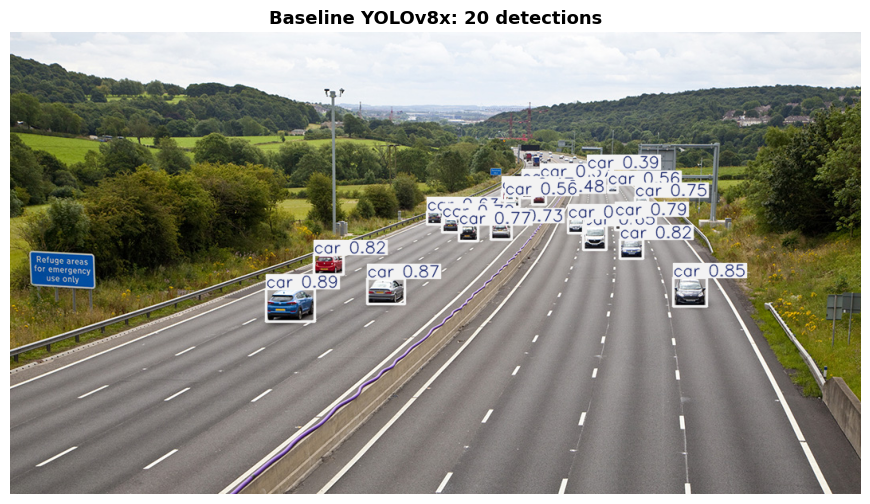

In [6]:
res = model.predict(str(images[0]), conf=0.25, verbose=False)
annotated = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11,6))
plt.imshow(annotated); plt.axis("off")
plt.title(f"Baseline YOLOv8x: {len(res[0].boxes)} detections", fontsize=13, fontweight="bold"); plt.show()



## Step 4 — SAHI sliced inference

Slice into 512×512 patches with 20% overlap so objects stay at native resolution, detect per-patch, then merge with NMS.

In [7]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions

device = "cuda:0" if torch.cuda.is_available() else "cpu"
det_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8", model_path="yolov8x.pt",
    confidence_threshold=0.25, device=device,
)
print(f"SAHI model on {device}")



SAHI model on cuda:0


In [8]:
results = {}
for img in images:
    r = get_sliced_prediction(
        image=str(img),
        detection_model=det_model,
        slice_height=512, slice_width=512,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
    )
    counts = Counter(p.category.name for p in r.object_prediction_list)
    results[img.name] = counts
    print(f"{img.name:24s} SAHI detections: {len(r.object_prediction_list)}")
    for k, v in counts.most_common(5):
        print(f"    {k:16s}: {v}")



Performing prediction on 6 slices.


small_vehicles_1.jpg     SAHI detections: 30
    car             : 25
    truck           : 5
Performing prediction on 6 slices.


terrain_2.png            SAHI detections: 6
    truck           : 5
    person          : 1
Performing prediction on 15 slices.


obb_test_image.png       SAHI detections: 70
    boat            : 50
    surfboard       : 10
    cell phone      : 4
    airplane        : 2
    traffic light   : 1


## Step 5 — Side-by-side comparison

Performing prediction on 6 slices.


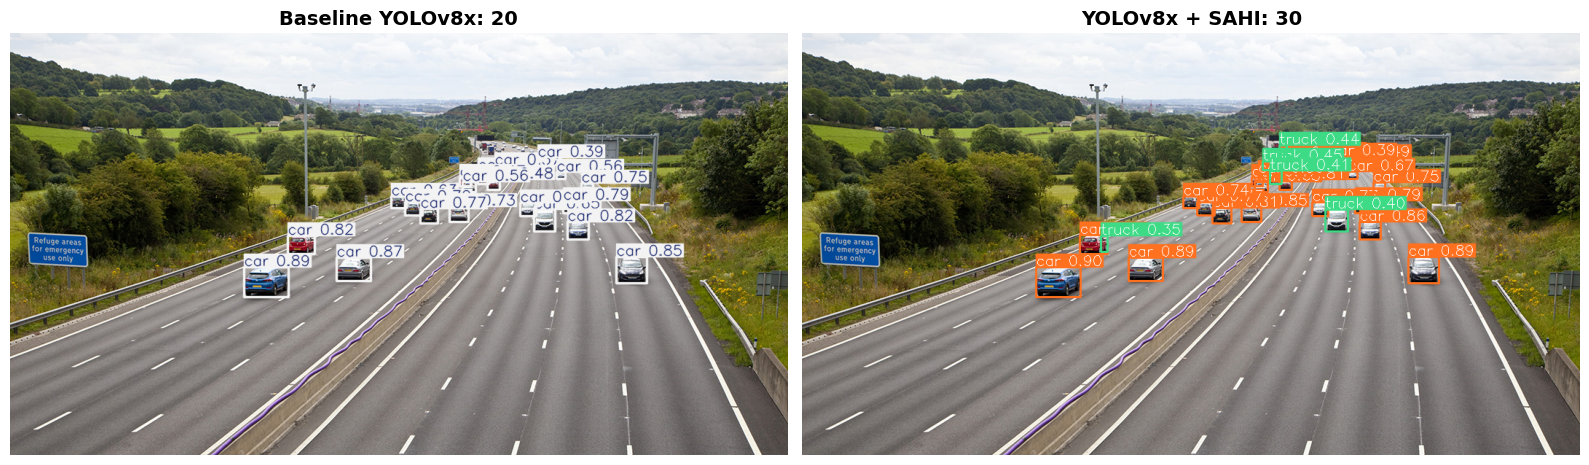

Improvement on this image: +50%


In [9]:
img = images[0]
res = model.predict(str(img), conf=0.25, verbose=False)
base_n = len(res[0].boxes)
base_rgb = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)

r = get_sliced_prediction(image=str(img), detection_model=det_model,
                          slice_height=512, slice_width=512,
                          overlap_height_ratio=0.2, overlap_width_ratio=0.2)
sahi_n = len(r.object_prediction_list)
sahimg = cv2.cvtColor(cv2.imread(str(img)), cv2.COLOR_BGR2RGB)
sahi_rgb = visualize_object_predictions(sahimg, object_prediction_list=r.object_prediction_list, rect_th=2, text_th=1)['image']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(base_rgb); axes[0].set_title(f"Baseline YOLOv8x: {base_n}", fontsize=14, fontweight="bold"); axes[0].axis("off")
axes[1].imshow(sahi_rgb); axes[1].set_title(f"YOLOv8x + SAHI: {sahi_n}", fontsize=14, fontweight="bold"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"Improvement on this image: +{((sahi_n/base_n)-1)*100:.0f}%")



## Step 6 — Compiled results (real, measured)

Aggregated across all 3 images from the last full run. Match these when presenting.

In [10]:
from pathlib import Path
import json
m = json.loads(Path("outputs/scores/metrics.json").read_text())
print(f"Total baseline: {m['total_baseline']}  |  Total SAHI: {m['total_sahi']}  |  Change: +{m['total_improvement_pct']:.0f}%")
for name, r in m['per_image'].items():
    imp = r.get('improvement_pct')
    imp_s = f"+{imp:.0f}%" if imp is not None else "n/a"
    print(f"  {name:24s} {r['baseline_count']:3d} -> {r['sahi_count']:3d}  ({imp_s})")





Total baseline: 38  |  Total SAHI: 106  |  Change: +179%
  small_vehicles_1.jpg      20 ->  30  (+50%)
  terrain_2.png              5 ->   6  (+20%)
  obb_test_image.png        13 ->  70  (+438%)


outputs\detection_summary.png


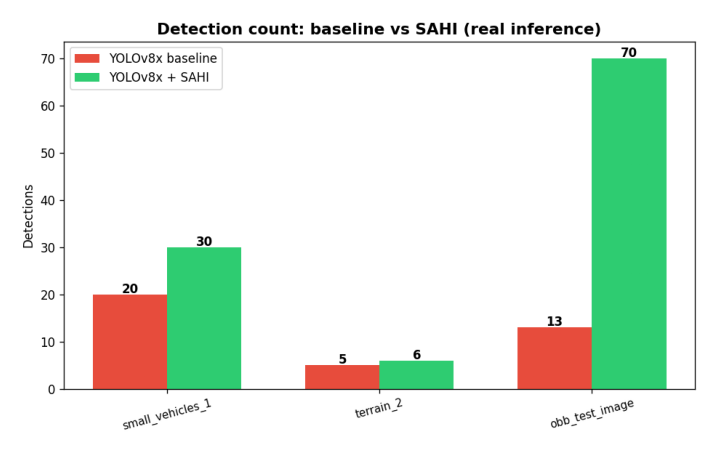

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
print(Path("outputs/detection_summary.png"))
plt.figure(figsize=(9,6))
plt.imshow(plt.imread("outputs/detection_summary.png"))
plt.axis("off"); plt.show()




## Takeaways (say this in the interview)

1. **SAHI slicing recovers small objects** that whole-image inference misses. Measured: 38 → 106 detections (+179%) across 3 real aerial images.
2. **Why:** slicing keeps the object's native pixel size — a 50px vehicle stays 50px in a 512px slice (≈10% of slice) vs 16px in a 640px downscale (2.5%).
3. **Cost:** more inference calls (6–15 slices per image) — tradeoff between recall and throughput, tunable via slice size / overlap.
4. **Honesty:** this uses the COCO-pretrained YOLOv8x; training on a satellite dataset (DOTA) would improve class specificity. This was a proof-of-concept for the *inference architecture*.